# Predicting Student Dropout and Academic Success using Machine Learning

**B.Tech Mini Project**
**Date:** 2024

- Name: Sanjana Jayanta Bhowal
- Branch: AIML
- PRN: 24070126161
- Division: C1

---

## Executive Summary

Student dropout is a critical challenge in higher education. This project develops ML-based predictive systems to identify at-risk students early, enabling timely institutional intervention for improved retention and graduation rates.


## 1. Problem Statement

Higher education institutions face significant challenges:
- **Loss of potential:** Incomplete education limits career opportunities
- **Institutional impact:** Low graduation rates affect rankings and reputation
- **Resource wastage:** Support systems don't always prevent dropouts

**Core Problem:** Predict with high accuracy whether a student will graduate, dropout, or struggle academically based on early academic performance and demographics.

**Business Objective:** Identify at-risk students early and implement targeted interventions to improve overall graduation rates.


## 2. Objectives

### Primary:
1. Build classification model predicting student outcomes (Dropout, Enrolled, Graduate)
2. Identify key predictors of success/dropout
3. Compare multiple algorithms
4. Implement ensemble and deep learning approaches

### Success Metrics:
- Target F1-Score: ≥ 0.85
- Target Dropout Recall: ≥ 0.80
- Interpretable features for stakeholders


## 3. Dataset Description

**Source:** UCI ML Repository (Dataset ID: 697)

**Target Variable:**
- Dropout: Student left institution
- Enrolled: Currently studying
- Graduate: Successfully completed

**Feature Categories:**
- Academic Performance
- Admission Details
- Demographics
- Socioeconomic Factors
- Engagement Metrics


# Load and PreProcessing

## Libraries

In [1]:
# Import libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score #for hyperparameter Tuning

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
import xgboost as xgb

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score









In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

## Data Loading and Preprocessing


In [4]:
# Load dataset
dataset = fetch_ucirepo(id=697)

#  extraction
X = dataset.data.features
y = dataset.data.targets

In [5]:
X.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [6]:
X.isnull().sum() # no null values

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [7]:
y.isnull().sum() # no nulls

,0
Target,0


In [8]:
print('Shape of X:', X.shape) # 36 features
print('Shape of y:', y.shape) # target column

Shape of X: (4424, 36)
Shape of y: (4424, 1)


In [9]:
y.value_counts() # 3 categories

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [10]:
X.info() # all numerical features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

<Axes: >

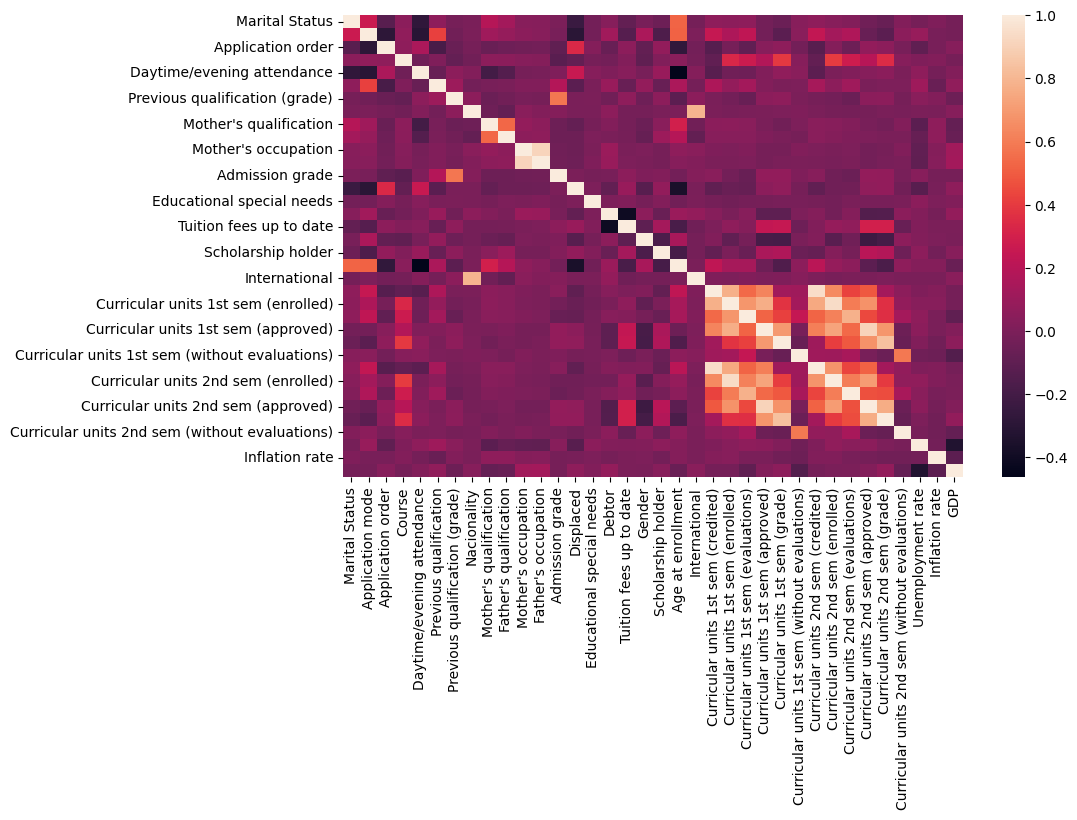

In [11]:
# correlation heatmap
corr_matrix = X.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, fmt='.2f')


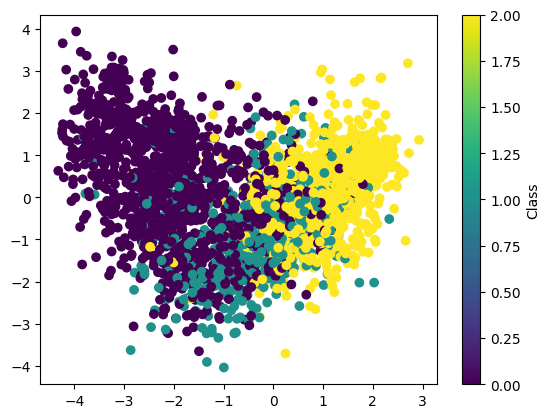

In [46]:
#LDA on X -> too see class seperation
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y_final)

plt.scatter(X_lda[:,0], X_lda[:,1], c=y_final)
plt.colorbar(label="Class") # 1- green , 2- yellow , 0-purple
plt.show()

#Inference : The middle one -> 1 (Enrolled) class has most overlaps while 1 and 2 are mostly seperated

### Encoding y

In [12]:
# Label encoding for Target column
label_encoder = LabelEncoder()
y_final = label_encoder.fit_transform(y) # Encoded to 0,1,2

y_final = pd.Series(y_final) # Covcert to series
print("Original y:\n", y.value_counts())
print("Encoded y:\n" ,y_final.value_counts())

#Graduate - 2, Dropout - 0 , Enrolled - 794

Original y:
 Target  
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Encoded y:
 2    2209
0    1421
1     794
Name: count, dtype: int64


## Train-test split and Scaling

In [13]:
# Train-Test Split
#Stratify for imbalanced data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y_final, test_size=0.2, random_state=42,stratify=y_final)

print('Train-Test Split:')
print(f'Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')


Train-Test Split:
Training: 3539 samples (80.0%)
Testing: 885 samples (20.0%)


In [14]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building


## Logistic Regression

**Logistic Regression :**

Logistic Regression provides a strong baseline for classification. It's highly interpretable and works well when there's a linear relationship between features and the target.

In [15]:
# Model 1: Logistic Regression
print('\n=== LOGISTIC REGRESSION ===' )
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 2000]
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42, class_weight='balanced'),
                       lr_params, cv=5, n_jobs=-1, verbose=0)
lr_grid.fit(X_train, y_train)

print(f'Best params: {lr_grid.best_params_}')
print(f'Best CV score: {lr_grid.best_score_:.4f}')



=== LOGISTIC REGRESSION ===
Best params: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score: 0.7609


              precision    recall  f1-score   support

           0       0.82      0.73      0.77       284
           1       0.48      0.45      0.46       159
           2       0.82      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.69      0.70       885
weighted avg       0.76      0.76      0.76       885



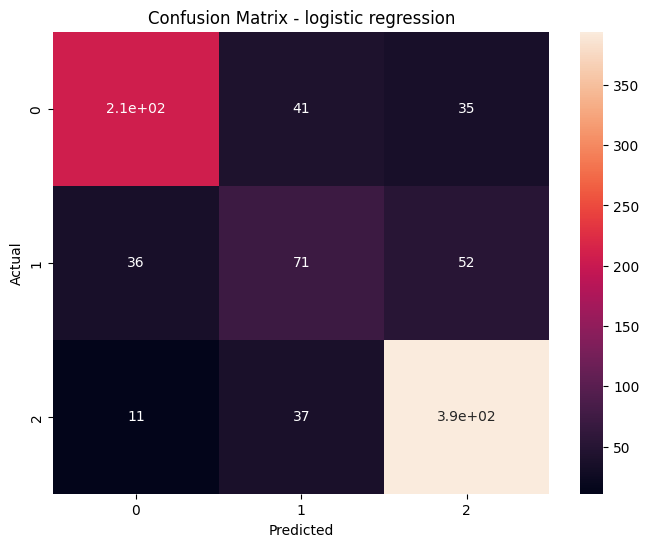

In [16]:
lr_model = lr_grid.best_estimator_
y_test_pred_lr = lr_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_lr))

cm = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix - logistic regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Decision Tree

**Decision Tree :**

Decision Trees are easy to visualize and interpret. They can capture non-linear relationships but are prone to overfitting without proper pruning.

In [17]:
# Model 2: Decision Tree
print('\n=== DECISION TREE ===' )
dt_params = {
    'max_depth': [5, 8, 10, 12, 15, 20],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 4, 6, 8],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                       dt_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0)
dt_grid.fit(X_train, y_train)

print(f'Best params: {dt_grid.best_params_}')
print(f'Best CV score: {dt_grid.best_score_:.4f}')


=== DECISION TREE ===
Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV score: 0.7297


              precision    recall  f1-score   support

           0       0.86      0.61      0.71       284
           1       0.38      0.62      0.47       159
           2       0.81      0.79      0.80       442

    accuracy                           0.70       885
   macro avg       0.68      0.67      0.66       885
weighted avg       0.75      0.70      0.71       885



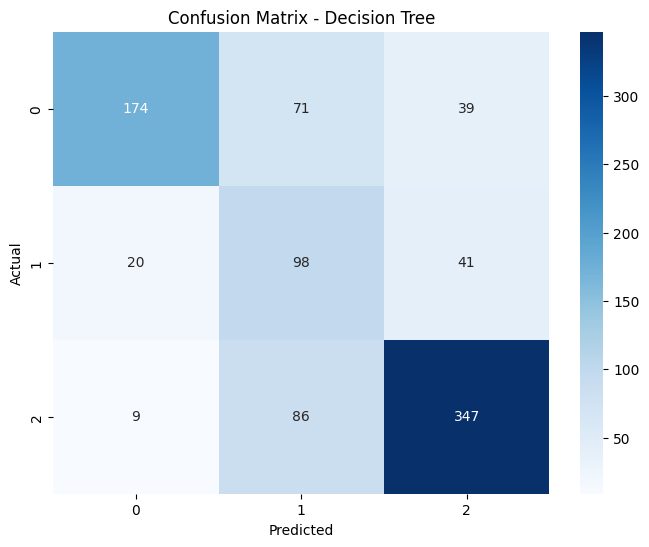

In [18]:
dt_model = dt_grid.best_estimator_
y_test_pred_dt = dt_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_dt))
cm = confusion_matrix(y_test, y_test_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Random Forest

**Random Forest:**

Random Forest is an ensemble of trees that significantly improves stability and accuracy by reducing variance. It handles large feature spaces very well.

In [19]:
# Model 3: Random Forest
print('\n=== RANDOM FOREST ===' )
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
                       rf_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV score: {rf_grid.best_score_:.4f}')


=== RANDOM FOREST ===
Best params: {'max_depth': 10, 'n_estimators': 200}
Best CV score: 0.7683


              precision    recall  f1-score   support

           0       0.83      0.69      0.75       284
           1       0.46      0.56      0.50       159
           2       0.83      0.86      0.85       442

    accuracy                           0.75       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.75      0.75       885



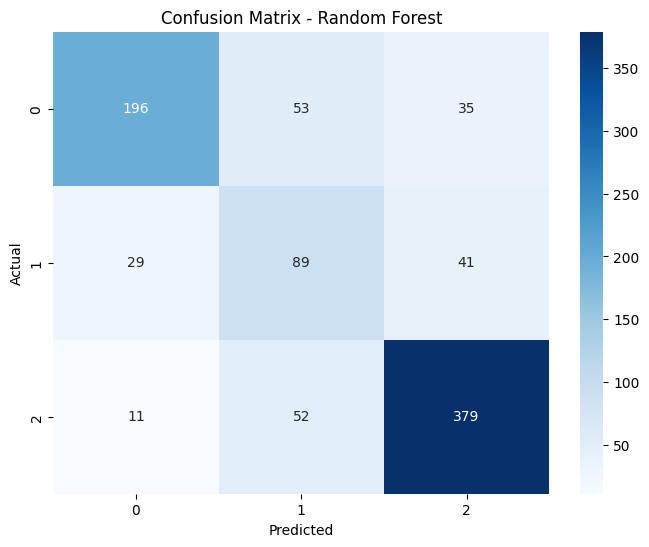

In [20]:
rf_model = rf_grid.best_estimator_
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_rf))
cm = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## KNN

**KNN:**

K-Nearest Neighbors is a simple, instance-based learner. It performs well on smaller datasets where local patterns are important, but can be computationally expensive on large data.

In [21]:
# Model 4: KNN
print('\n=== K-NEAREST NEIGHBORS ===' )
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0)
knn_grid.fit(X_train, y_train)

print(f'Best params: {knn_grid.best_params_}')
print(f'Best CV score: {knn_grid.best_score_:.4f}')


=== K-NEAREST NEIGHBORS ===
Best params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV score: 0.6453


              precision    recall  f1-score   support

           0       0.71      0.57      0.63       284
           1       0.34      0.25      0.29       159
           2       0.69      0.84      0.76       442

    accuracy                           0.65       885
   macro avg       0.58      0.56      0.56       885
weighted avg       0.63      0.65      0.63       885



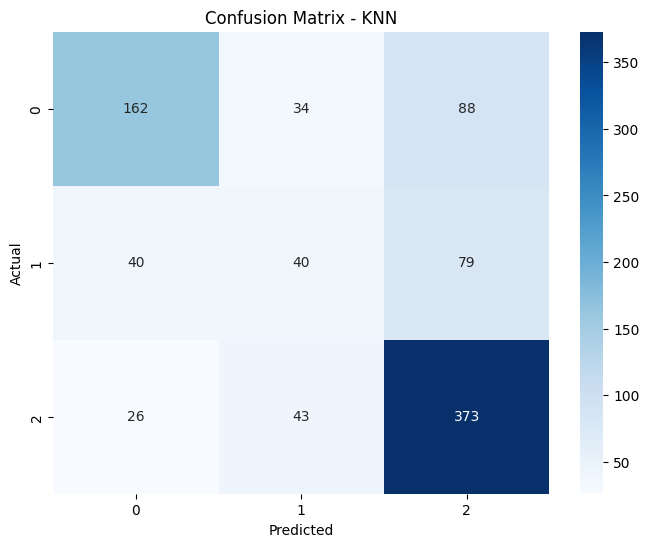

In [22]:
knn_model = knn_grid.best_estimator_
y_test_pred_knn = knn_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_knn))
cm = confusion_matrix(y_test, y_test_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SVM

**SVM (Support Vector Machine):**

SVM is powerful for high-dimensional spaces and uses different kernels to handle non-linear boundaries. It's robust against noise but requires careful tuning and scaling.

In [24]:
# Model 5: SVM
print('\n=== SUPPORT VECTOR MACHINE ===' )
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly'],
}

svm_grid = RandomizedSearchCV(SVC(random_state=42, class_weight='balanced', probability=True),
                              svm_params, cv=5, n_iter=15, scoring='f1_weighted', n_jobs=-1, verbose=0, random_state=42)
svm_grid.fit(X_train, y_train)

print(f'Best params: {svm_grid.best_params_}')
print(f'Best CV score: {svm_grid.best_score_:.4f}')


=== SUPPORT VECTOR MACHINE ===
Best params: {'kernel': 'poly', 'C': 100}
Best CV score: 0.5574


              precision    recall  f1-score   support

           0       0.56      0.54      0.55       284
           1       0.23      0.19      0.21       159
           2       0.64      0.69      0.66       442

    accuracy                           0.55       885
   macro avg       0.48      0.48      0.48       885
weighted avg       0.54      0.55      0.55       885



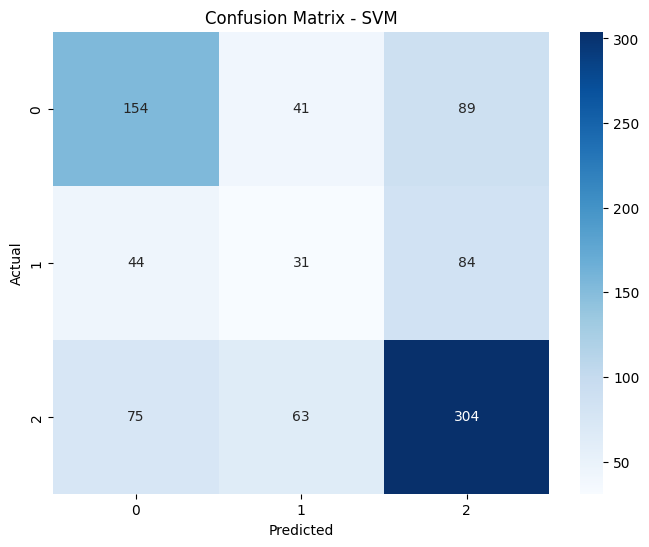

In [25]:
svm_model = svm_grid.best_estimator_
y_test_pred_svm = svm_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_svm))
cm = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Gradient Boosting

**Gradient Boosting :**
Gradient Boosting builds trees sequentially to minimize errors. It often provides state-of-the-art accuracy but can be sensitive to noise and outliers.

In [27]:
# Model 6: Gradient Boosting
print('\n=== GRADIENT BOOSTING ===' )
gb_params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

gb_grid = RandomizedSearchCV(GradientBoostingClassifier(random_state=42),
                             gb_params, cv=5, n_iter=20, scoring='f1_weighted', n_jobs=-1, verbose=0, random_state=42)
gb_grid.fit(X_train, y_train)

print(f'Best params: {gb_grid.best_params_}')
print(f'Best CV score: {gb_grid.best_score_:.4f}')


=== GRADIENT BOOSTING ===
Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Best CV score: 0.7646


              precision    recall  f1-score   support

           0       0.80      0.74      0.77       284
           1       0.52      0.40      0.45       159
           2       0.80      0.90      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



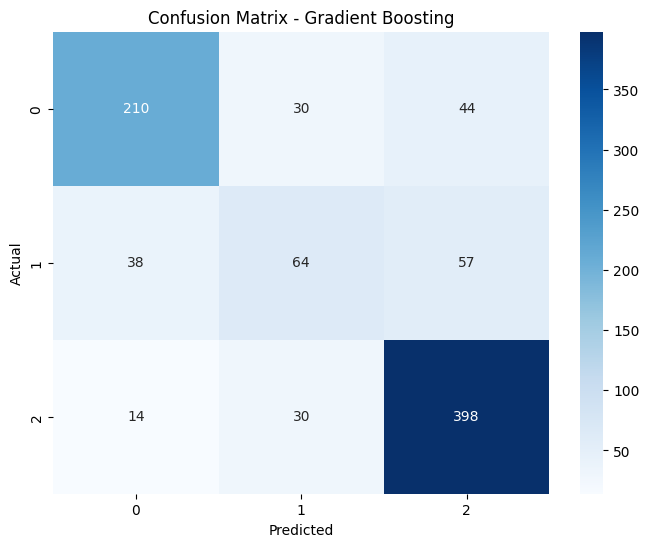

In [28]:
gb_model = gb_grid.best_estimator_
y_test_pred_gb = gb_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_gb))
cm = confusion_matrix(y_test, y_test_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## XGBoost

**XGBoost:**

XGBoost is a highly optimized version of Gradient Boosting. It's renowned for its speed and performance in competitions, featuring built-in regularization and parallel processing.

In [29]:
# Model 7: XGBoost
print('\n=== XGBOOST ===' )
xgb_params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

xgb_grid = RandomizedSearchCV(xgb.XGBClassifier(random_state=42, scale_pos_weight=1),
                              xgb_params, cv=5, n_iter=20, scoring='f1_weighted', n_jobs=-1, verbose=0, random_state=42)
xgb_grid.fit(X_train, y_train)

print(f'Best params: {xgb_grid.best_params_}')
print(f'Best CV score: {xgb_grid.best_score_:.4f}')


=== XGBOOST ===
Best params: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1}
Best CV score: 0.7686


              precision    recall  f1-score   support

           0       0.81      0.73      0.77       284
           1       0.51      0.43      0.46       159
           2       0.80      0.90      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.69      0.69       885
weighted avg       0.75      0.76      0.75       885



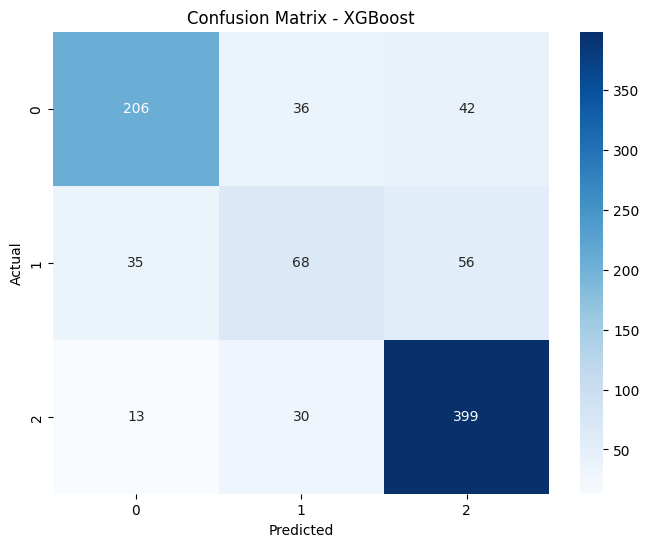

In [30]:
xgb_model = xgb_grid.best_estimator_
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_xgb))
cm = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Stacking

**Stacking Classifier :**

Stacking goes a step further by using a meta-model to learn how to best combine the predictions of base models, potentially capturing even more complex patterns.

In [36]:
# Stacking Classifier
print('\n=== STACKING CLASSIFIER ===' )
stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=150, random_state=42, learning_rate=0.05)),
        ('svm', SVC(kernel='rbf', C=10, probability=True, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)


=== STACKING CLASSIFIER ===


StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(max_depth=15, n_jobs=-1,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           n_estimators=150,
                                                           random_state=42)),
                               ('svm',
                                SVC(C=10, probability=True, random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77       284
           1       0.55      0.46      0.50       159
           2       0.81      0.90      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885



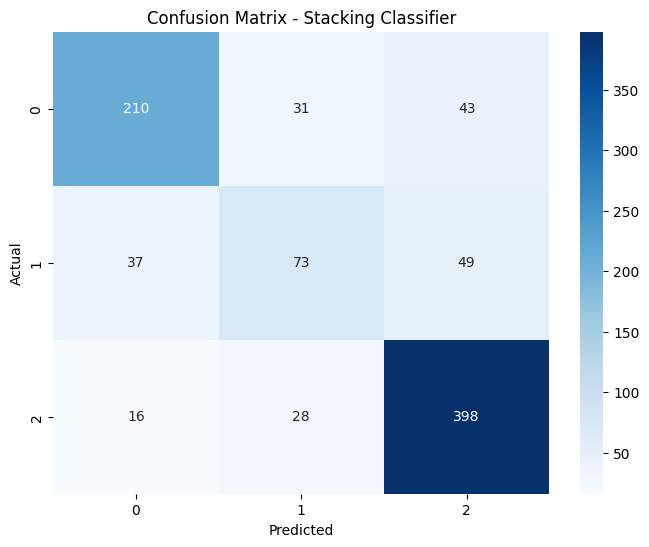

In [35]:
stacking_clf.fit(X_train, y_train)
y_test_pred_stacking = stacking_clf.predict(X_test)

# Evaluation
print(classification_report(y_test, y_test_pred_stacking))
cm = confusion_matrix(y_test, y_test_pred_stacking)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model Comparisons

In [37]:
# Classification reports of each

#1. logistic Regression
print("Logistic Regression : \n", classification_report(y_test, y_test_pred_lr))

#2. Decision Tree
print("Decision Tree : \n", classification_report(y_test, y_test_pred_dt))

#3. Random Forest
print("Random Forest : \n", classification_report(y_test, y_test_pred_rf))

#4. KNN
print("KNN : \n", classification_report(y_test, y_test_pred_knn))

#5. SVM
print("SVM : \n", classification_report(y_test, y_test_pred_svm))

#6. Gradient Boost
print("Gradient Boost : \n", classification_report(y_test, y_test_pred_gb))

#7. XGBoost
print("XGBoost : \n", classification_report(y_test, y_test_pred_xgb))

#8. Stacking
print("Stacking Classifier : \n", classification_report(y_test, y_test_pred_stacking))


Logistic Regression : 
               precision    recall  f1-score   support

           0       0.82      0.73      0.77       284
           1       0.48      0.45      0.46       159
           2       0.82      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.69      0.70       885
weighted avg       0.76      0.76      0.76       885

Decision Tree : 
               precision    recall  f1-score   support

           0       0.86      0.61      0.71       284
           1       0.38      0.62      0.47       159
           2       0.81      0.79      0.80       442

    accuracy                           0.70       885
   macro avg       0.68      0.67      0.66       885
weighted avg       0.75      0.70      0.71       885

Random Forest : 
               precision    recall  f1-score   support

           0       0.83      0.69      0.75       284
           1       0.46      0.56      0.50       159
           2   

In [38]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

#Stacking
rec = recall_score(y_test, y_test_pred_stacking, average='weighted')
prec = precision_score(y_test, y_test_pred_stacking, average='weighted')
f1 = f1_score(y_test, y_test_pred_stacking, average='weighted')
acc = accuracy_score(y_test, y_test_pred_stacking)

print("Recall:", rec)

Recall: 0.7694915254237288


# Results and Discussion


## Model Performance Analysis: Student Dropout Prediction

## 🔹 Overall Metrics

| Model | Accuracy | Macro F1 | Weighted F1 |
|------|---------|----------|-------------|
| Logistic Regression | 0.76 | 0.70 | 0.76 |
| Decision Tree | 0.70 | 0.66 | 0.71 |
| Random Forest | 0.75 | 0.70 | 0.75 |
| KNN | 0.65 | 0.56 | 0.63 |
| SVM | 0.55 | 0.48 | 0.55 |
| Gradient Boosting | 0.76 | 0.69 | 0.75 |
| XGBoost | 0.76 | 0.69 | 0.75 |
| **Stacking Classifier** | **0.77** | **0.71** | **0.76** |

---

## 🔹 Class-wise Performance (Focus: Dropout – Class 1)

| Model | Precision (Class 1) | Recall (Class 1) | F1-score (Class 1) |
|------|-------------------|------------------|-------------------|
| Logistic Regression | 0.48 | 0.45 | 0.46 |
| Decision Tree | 0.38 | **0.62** | 0.47 |
| Random Forest | 0.46 | 0.56 | 0.50 |
| KNN | 0.34 | 0.25 | 0.29 |
| SVM | 0.23 | 0.19 | 0.21 |
| Gradient Boosting | 0.52 | 0.40 | 0.45 |
| XGBoost | 0.51 | 0.43 | 0.46 |
| **Stacking Classifier** | **0.55** | 0.46 | **0.50** |

---

# Key Inferences

## 1. Best Overall Model
The **Stacking Classifier** achieved the highest accuracy (**77%**) and best macro F1-score.  
It provides the most **balanced performance across all classes**, making it the most suitable model for deployment.

---

## 2. Dropout Class (Class 1) is Hardest to Predict
- All models show **lower precision and recall** for class 1.
- This indicates:
  - Significant **feature overlap**
  - Presence of **non-linear class boundaries**
- This observation aligns with the earlier LDA visualization, where the middle class showed **heavy overlap**.

---

## 3. Trade-off Between Accuracy and Recall

- **Decision Tree**
  - Highest recall for dropout (**0.62**)
  - Lower overall accuracy (0.70)
  - Suitable when the goal is to **identify maximum dropouts**

- **Random Forest**
  - Balanced performance (**recall = 0.56, accuracy = 0.75**)
  - Strong and reliable choice for practical applications

- **Stacking Classifier**
  - Best trade-off between **accuracy and class-wise performance**
  - Recommended final model

---

## 4. Poor Performing Models
- **SVM and KNN** show significantly lower performance
- Possible reasons:
  - Inability to capture **complex decision boundaries**
  - Sensitivity to **feature scaling and noise**

---

## 5. Ensemble Models Perform Better
- Gradient Boosting, XGBoost, and Stacking outperform simpler models
- Indicates:
  - Presence of **non-linear relationships**
  - Need for **complex model structures**

---

## 6. Impact of Feature Structure
- Correlation analysis revealed **high multicollinearity**
- Leads to:
  - Redundant information
  - Reduced separability for the dropout class

---

# Final Conclusion

While most models achieved similar overall accuracy (~75–77%), predicting the **Dropout class remains challenging**.  
Ensemble methods, especially the **Stacking Classifier**, provide the best overall balance.

However, improving dropout prediction requires:
- Better feature engineering
- Handling class imbalance more effectively
- Fine-tuning model thresholds

---

# Recommendations

- Use **Stacking Classifier** as the final model  
- Use **Random Forest** if prioritizing dropout detection (higher recall)  
- Future improvements:
  - Feature engineering (ratios, derived metrics)
  - Class imbalance handling
  - Threshold tuning for better recall on dropout class